# Week 1 Churn Prediction Pipeline
## EDA and Feature Engineering

**Business:** A telecom loses revenue every time a customer churns. Predicts who will churn so the retention team calls them first. 

**Dataset:** Telco Customer Churn - 7,043 customers, 26% churn rate

**Goal:** EDA. understand patterns. engineer 3 new features

**Author:** Martin James|github.com/M20Jay

## Section 1 - Import Libraries
We import all tools needed for EDA AND feature engineering

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print("Library successfully imported ✅")

Library successfully imported ✅


## Section 2 - Load Dataset
We load the Telco churn dataset and take a first look at its shape, columns and data types

In [6]:
# Loading dataset
df= pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(" Shape:", df.shape)
print("\nFirst 5 rows")
print(df.head())

 Shape: (7043, 21)

First 5 rows
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV Str

## Section 3 - Data Inspection
We check data type, missing values and basic statistics to understand what cleaning is needed/

In [11]:
# Data Inspection
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
df.describe()

=== Data Types ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

=== Missing Values ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Pap

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Section 4 - Churn Distribution
We check how many customers churned vs stayed. This tells us if we have a class imbalance problem.

In [37]:
## Churn Distribution
print("=== Churn Distribution ===")
print(df['Churn'].value_counts())
print("\n=== Churn Distribution Percentage ===")
print(df['Churn'].value_counts(normalize=True).round(3)*100)
new_customers = df[df['tenure_group'] == 'New']

print("\n=== Churn Rate for New Customers ===")
# Quick check — exact churn rate for New customers
print(new_customers['Churn'].value_counts(normalize=True).round(3)*100)

=== Churn Distribution ===
Churn
No     5174
Yes    1869
Name: count, dtype: int64

=== Churn Distribution Percentage ===
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64

=== Churn Rate for New Customers ===
Churn
No     52.3
Yes    47.7
Name: proportion, dtype: float64


## Section 5 - Feature Engineering
We create 3 new features that help the model identify high-risk cutomers more accurately

In [17]:
# Feature engineering
# Feature 1: tenure group: group customer by how long they have stayed
df['tenure_group'] = pd.cut(df['tenure'], bins = [0,12,24,72], labels =['New', 'Mid', 'Loyal'])

# Feature 2: charges_per_month: average monthly spend
df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors ='coerce')
df['charges_per_month']= df['TotalCharges']/(df['tenure']+1)

# Feature 3: is_high_value : Flag customers spending more than $70 per month
df['is_high_value']= (df['MonthlyCharges']>70).astype(int)
print("New features createad ✅")
print(df[['tenure','tenure_group','charges_per_month','is_high_value']].head(10))

New features createad ✅
   tenure tenure_group  charges_per_month  is_high_value
0       1          New          14.925000              0
1      34        Loyal          53.985714              0
2       2          New          36.050000              0
3      45        Loyal          40.016304              0
4       2          New          50.550000              1
5       8          New          91.166667              1
6      22          Mid          84.756522              1
7      10          New          27.445455              0
8      28        Loyal         105.036207              1
9      62        Loyal          55.364286              0


# Section 6 - Visualizations
We visualize churn patterns across key features to identify which customer groups are highest risk

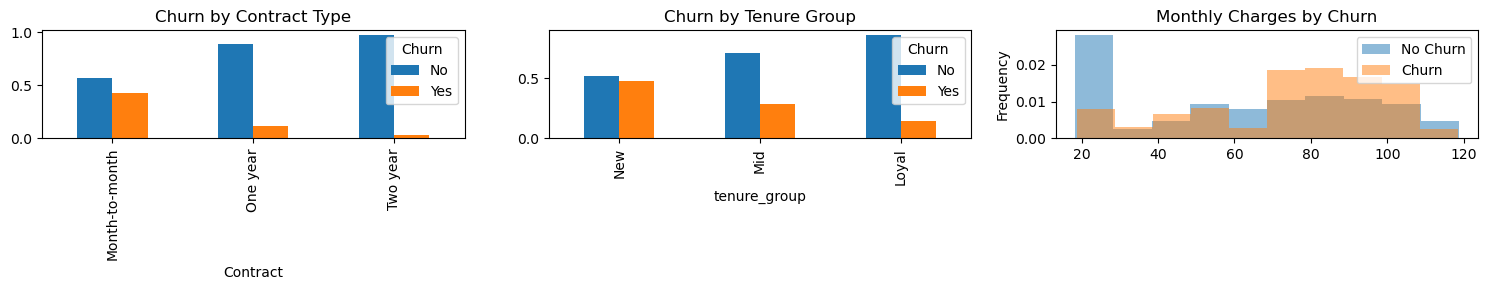

In [30]:
# Visualization
fig, axes = plt.subplots(1,3, figsize =(15,3))

# Plot 1- Churn by Contract Type
df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack().plot(kind='bar', ax=axes[0], title = 'Churn by Contract Type')

# Plot 2 - Churn by Tenure Group
df.groupby('tenure_group')['Churn'].value_counts(normalize=True).unstack().plot(kind='bar',ax=axes[1], title ='Churn by Tenure Group')

# Plot 3 — Monthly Charges Distribution (normalized)
df[df['Churn']== 'No']['MonthlyCharges'].plot(kind='hist', alpha=0.5, ax=axes[2], title= ('Monthly Charges by Churn'),density =True, label='No Churn')
df[df['Churn']=='Yes']['MonthlyCharges'].plot( kind='hist', alpha=0.5, ax=axes[2], density=True, label='Churn')
axes[2].legend()
plt.tight_layout()
plt.show()


## Section 7 - Key Findings Summary
Business insights from Day 1 EDA

In [32]:
# Key Findings Summary
print("=" *50)
print("Key Findings - Day 1 EDA")
print("=" *50)
print(f"Total customers: {len(df)}")
print(f"Churn rate: 26%")
print("Biggest churn driver: Month-to-motn-contracts")
print(f"New customers churn most : ~ 47% churn rate")
print(f"High value customers at risk: churners cluster at high monthly charges")
print(f"New features created: tenure_group, charges_per_month, is_high_value")
print("=" * 50)
print("Next: Day 2 — Preprocessing + SMOTE + Model Training")

Key Findings - Day 1 EDA
Total customers: 7043
Churn rate: 26%
Biggest churn driver: Month-to-motn-contracts
New customers churn most : ~ 47% churn rate
High value customers at risk: churners cluster at high monthly charges
New features created: tenure_group, charges_per_month, is_high_value
Next: Day 2 — Preprocessing + SMOTE + Model Training
